In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_core langgraph langchain_ollama

In [2]:
from langchain_ollama import ChatOllama

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
llm = ChatOllama(model="llama3.1", temperature=0)
llm_with_tools = llm.bind_tools(tools)

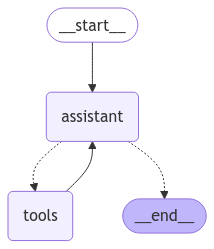

In [3]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(checkpointer=MemorySaver())

# Show
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [4]:
# Input
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (652bdb65-d51d-4d99-b087-517784563304)
 Call ID: 652bdb65-d51d-4d99-b087-517784563304
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [5]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2024-12-20T11:22:13.359768Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2271079084, 'load_duration': 12721167, 'prompt_eval_count': 299, 'prompt_eval_duration': 1365000000, 'eval_count': 22, 'eval_duration': 892000000, 'message': {'role': 'assistant', 'content': '', 'images': None, 'tool_calls': None}}, id='run-d29e19ff-4024-4b49-8d87-4f63ac9b0e51-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '652bdb65-d51d-4d99-b087-517784563304', 'type': 'tool_call'}], usage_metadata={'input_tokens': 299, 'output_tokens': 22, 'total_tokens': 321}), ToolMessage(content='6', name='multiply', id='b6311a25-123d-48c0-bcaf-752e4e8c6bca', tool_call_id='652bdb65-d51d-4d99-b087-517784563304'), AIMessage(content='The

In [6]:
all_states = [s for s in graph.get_state_history(thread)]

In [7]:
len(all_states)

5

In [8]:
all_states[-2]

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1efbec4a-7dc2-6f32-8000-c23a8d5103fd'}}, metadata={'source': 'loop', 'writes': None, 'thread_id': '1', 'step': 0, 'parents': {}}, created_at='2024-12-20T11:22:11.086711+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1efbec4a-7dbf-6436-bfff-c3ae192030b6'}}, tasks=(PregelTask(id='b9ad9669-af86-dfd2-bf4b-eff7425b54be', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2024-12-20T11:22:13.359768Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2271079084, 'load_duration': 12721167, 'prompt_eval_count': 299,

In [9]:
to_replay = all_states[-2]
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1efbec4a-7dc2-6f32-8000-c23a8d5103fd'}}, metadata={'source': 'loop', 'writes': None, 'thread_id': '1', 'step': 0, 'parents': {}}, created_at='2024-12-20T11:22:11.086711+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1efbec4a-7dbf-6436-bfff-c3ae192030b6'}}, tasks=(PregelTask(id='b9ad9669-af86-dfd2-bf4b-eff7425b54be', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2024-12-20T11:22:13.359768Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2271079084, 'load_duration': 12721167, 'prompt_eval_count': 299,

In [10]:
to_replay.values

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5')]}

In [11]:
to_replay.next

('assistant',)

In [12]:
to_replay.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1efbec4a-7dc2-6f32-8000-c23a8d5103fd'}}

In [13]:
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (04212faa-be31-441f-bd4a-93e6c1e42a89)
 Call ID: 04212faa-be31-441f-bd4a-93e6c1e42a89
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [14]:
to_fork = all_states[-2]
to_fork.values["messages"]

[HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5')]

In [15]:
to_fork.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1efbec4a-7dc2-6f32-8000-c23a8d5103fd'}}

In [16]:
fork_config = graph.update_state(
    to_fork.config,
    {"messages": [HumanMessage(content='Multiply 5 and 3', 
                               id=to_fork.values["messages"][0].id)]},
)

In [17]:
fork_config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1efbec4a-b951-67b0-8001-1a36263261dd'}}

In [18]:
all_states = [state for state in graph.get_state_history(thread) ]
all_states[0].values["messages"]

[HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5')]

In [19]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1efbec4a-b951-67b0-8001-1a36263261dd'}}, metadata={'source': 'update', 'writes': {'__start__': {'messages': [HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5')]}}, 'thread_id': '1', 'step': 1, 'parents': {}, 'checkpoint_ns': '', 'checkpoint_id': '1efbec4a-7dc2-6f32-8000-c23a8d5103fd'}, created_at='2024-12-20T11:22:17.331690+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1efbec4a-7dc2-6f32-8000-c23a8d5103fd'}}, tasks=(PregelTask(id='14a86345-41fa-b253-aa72-be3fa68ff9ce', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),))

In [20]:
for event in graph.stream(None, fork_config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 5 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (aa38a221-fc94-4838-87bc-44c47e61e8c6)
 Call ID: aa38a221-fc94-4838-87bc-44c47e61e8c6
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The result of multiplying 5 and 3 is 15.


In [21]:
graph.get_state({'configurable': {'thread_id': '1'}})

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 5 and 3', additional_kwargs={}, response_metadata={}, id='6a0fe863-0fd8-4c9f-a808-8e63605b55d5'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2024-12-20T11:22:19.49018Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2141280291, 'load_duration': 12197708, 'prompt_eval_count': 299, 'prompt_eval_duration': 1255000000, 'eval_count': 22, 'eval_duration': 873000000, 'message': {'role': 'assistant', 'content': '', 'images': None, 'tool_calls': None}}, id='run-d204213a-455a-4dba-894c-8e06e5fade63-0', tool_calls=[{'name': 'multiply', 'args': {'a': 5, 'b': 3}, 'id': 'aa38a221-fc94-4838-87bc-44c47e61e8c6', 'type': 'tool_call'}], usage_metadata={'input_tokens': 299, 'output_tokens': 22, 'total_tokens': 321}), ToolMessage(content='15', name='multiply', id='47874708-6020-4773-89db-a61cc13c391e', tool_call_id='aa38a221-fc94-4838-87bc-44c47e61e8c6'), AIMessage(content='The